# Solution: Challenge Week 11

## Libraries and settings

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output

# Show current working directory
print(os.getcwd())

/workspace/Week_11/challenge


## Model settings

In [2]:
# ── User-defined parameters ──────────────────────────────────────────
GRID_SIZE   = 5      # Number of cells in both x and y direction
N_ITER      = 200     # Total number of simulation iterations
PAUSE       = 0.05    # Pause between frames in seconds
# ─────────────────────────────────────────────────────────────────────

print(f'Grid size  : {GRID_SIZE} x {GRID_SIZE} ({GRID_SIZE**2} cells)')
print(f'Iterations : {N_ITER}')

Grid size  : 5 x 5 (25 cells)
Iterations : 200


## Define the Agent class

In [3]:
class Agent:
    """
    An agent that moves randomly on a quadratic grid.

    Attributes
    ----------
    name      : str   -- Display name of the agent.
    color     : str   -- Matplotlib color for the agent's cell.
    grid_size : int   -- Number of cells in each direction.
    row       : int   -- Current row position (0-based).
    col       : int   -- Current column position (0-based).
    """

    # Possible moves: stay, up, down, left, right
    _MOVES = [(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)]

    def __init__(self, name, color, grid_size, start_row=None, start_col=None):
        self.name      = name
        self.color     = color
        self.grid_size = grid_size
        # Random start position if not provided
        self.row = start_row if start_row is not None else random.randint(0, grid_size - 1)
        self.col = start_col if start_col is not None else random.randint(0, grid_size - 1)

    def move(self):
        """Move one step in a random direction (wrap-around at borders)."""
        dr, dc   = random.choice(self._MOVES)
        self.row = (self.row + dr) % self.grid_size
        self.col = (self.col + dc) % self.grid_size

    @property
    def position(self):
        """Return current (row, col) position."""
        return (self.row, self.col)

## Run the simulation

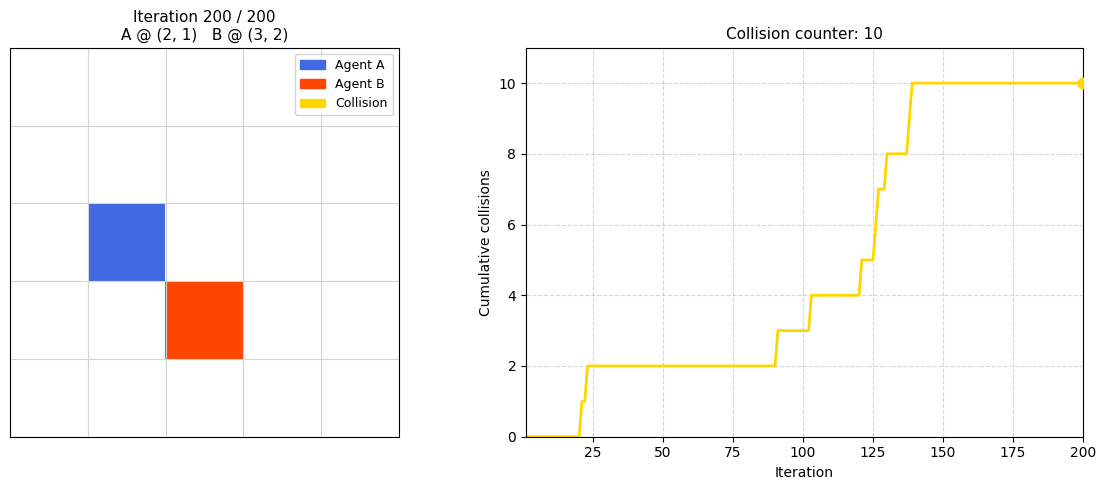


Simulation finished.
Total collisions in 200 iterations: 10


In [4]:
# Initialise the two agents at random starting positions
random.seed(42)
agent_a = Agent('Agent A', color='royalblue',  grid_size=GRID_SIZE)
agent_b = Agent('Agent B', color='orangered',  grid_size=GRID_SIZE)

# Collision counter
collision_count = 0

# History lists (for the summary plot)
history_a   = []
history_b   = []
collision_history = []

# ── Simulation loop ───────────────────────────────────────────────────
for iteration in range(N_ITER):

    # Move agents
    agent_a.move()
    agent_b.move()

    # Check for collision
    collision = agent_a.position == agent_b.position
    if collision:
        collision_count += 1

    # Record state
    history_a.append(agent_a.position)
    history_b.append(agent_b.position)
    collision_history.append(collision_count)

    # ── Build grid array ──────────────────────────────────────────────
    # 0 = empty  1 = Agent A  2 = Agent B  3 = both (collision)
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    grid[agent_a.row, agent_a.col] = 1

    if collision:
        grid[agent_b.row, agent_b.col] = 3
    else:
        grid[agent_b.row, agent_b.col] = 2

    # ── Draw the frame ────────────────────────────────────────────────
    # Colour map: 0=white, 1=royalblue, 2=orangered, 3=gold (collision)
    cmap   = plt.cm.colors.ListedColormap(['white', 'royalblue', 'orangered', 'gold'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm   = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             gridspec_kw={'width_ratios': [1, 1]})

    # Left panel: current grid state
    ax_grid = axes[0]
    ax_grid.imshow(grid, cmap=cmap, norm=norm, origin='upper')
    ax_grid.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax_grid.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax_grid.grid(which='minor', color='lightgrey', linewidth=0.8)
    ax_grid.tick_params(which='both', bottom=False, left=False,
                        labelbottom=False, labelleft=False)
    ax_grid.set_title(
        f'Iteration {iteration + 1} / {N_ITER}\n'
        f'A @ {agent_a.position}   B @ {agent_b.position}',
        fontsize=11
    )

    # Legend
    legend_patches = [
        mpatches.Patch(color='royalblue', label='Agent A'),
        mpatches.Patch(color='orangered', label='Agent B'),
        mpatches.Patch(color='gold',      label='Collision'),
    ]
    ax_grid.legend(handles=legend_patches, loc='upper right',
                   fontsize=9, framealpha=0.85)

    # Right panel: cumulative collision counter over time
    ax_cnt = axes[1]
    ax_cnt.plot(range(1, iteration + 2), collision_history,
                color='gold', linewidth=2)
    ax_cnt.scatter([iteration + 1], [collision_count],
                   color='gold', s=60, zorder=5)
    ax_cnt.set_xlim(1, N_ITER)
    ax_cnt.set_ylim(0, max(collision_history[-1] + 1, 2))
    ax_cnt.set_xlabel('Iteration')
    ax_cnt.set_ylabel('Cumulative collisions')
    ax_cnt.set_title(f'Collision counter: {collision_count}', fontsize=11)
    ax_cnt.grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    clear_output(wait=True)
    plt.show()
    plt.pause(PAUSE)

print(f'\nSimulation finished.')
print(f'Total collisions in {N_ITER} iterations: {collision_count}')

## Simulation summary

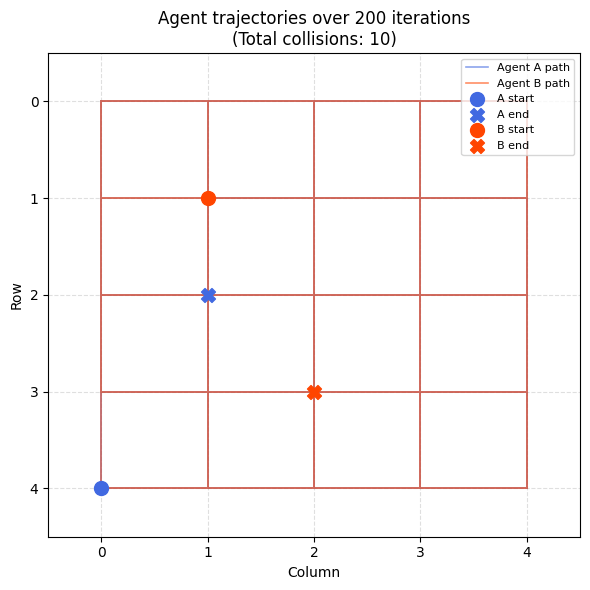

In [5]:
# Trajectory plot: paths of both agents across all iterations
rows_a, cols_a = zip(*history_a)
rows_b, cols_b = zip(*history_b)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(cols_a, rows_a, color='royalblue', alpha=0.6, linewidth=1.2, label='Agent A path')
ax.plot(cols_b, rows_b, color='orangered', alpha=0.6, linewidth=1.2, label='Agent B path')

# Mark start and end positions
ax.scatter(cols_a[0],  rows_a[0],  color='royalblue', marker='o', s=100, zorder=5, label='A start')
ax.scatter(cols_a[-1], rows_a[-1], color='royalblue', marker='X', s=100, zorder=5, label='A end')
ax.scatter(cols_b[0],  rows_b[0],  color='orangered', marker='o', s=100, zorder=5, label='B start')
ax.scatter(cols_b[-1], rows_b[-1], color='orangered', marker='X', s=100, zorder=5, label='B end')

ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(GRID_SIZE - 0.5, -0.5)   # row 0 at top
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(linestyle='--', alpha=0.4)
ax.set_title(f'Agent trajectories over {N_ITER} iterations\n'
             f'(Total collisions: {collision_count})', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [6]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1044-azure
Datetime: 2026-04-22 15:49:09
Python Version: 3.11.14
-----------------------------------
